In [1]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr

### Empirical relationships (ignore model trends)

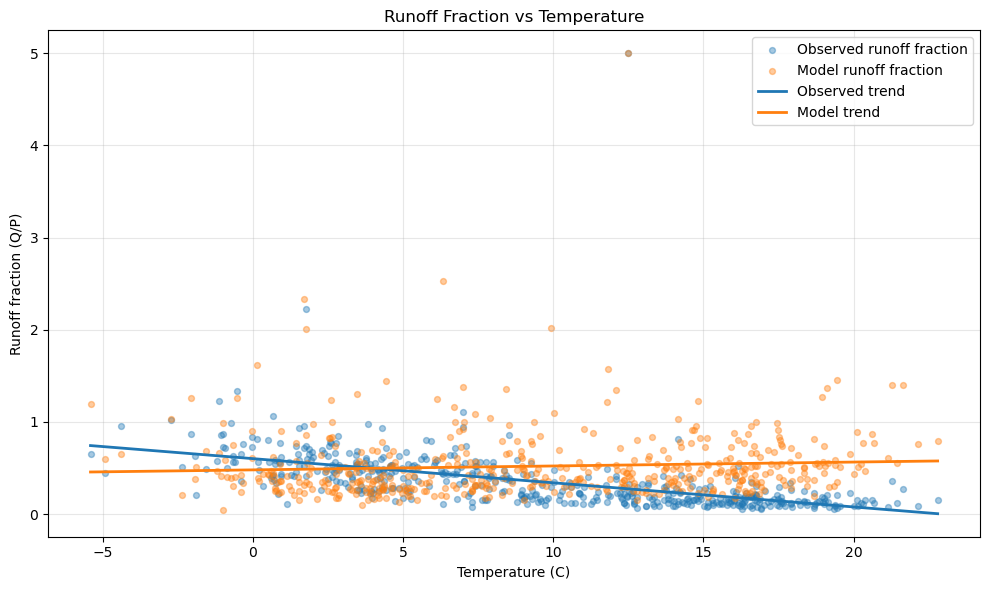

Observed trend slope: -0.0262 per C
Model trend slope:    0.0042 per C


In [ ]:
# import matplotlib.pyplot as plt

# # Quick hypothesis check: runoff fraction vs temperature
# # Runoff fraction here is Q/P (both in mm/day).
# #rf_df = check_df.copy()
# rf_df = rf_df[rf_df['precip_mm_day'] > 0.1].copy()
# rf_df['runoff_fraction_obs'] = rf_df['q_obs_mm_day'] / rf_df['precip_mm_day']
# #rf_df['runoff_fraction_model'] = best_sim_q / rf_df['precip_mm_day']

# # Keep extreme outliers from dominating the visual check
# rf_df['runoff_fraction_obs'] = rf_df['runoff_fraction_obs'].clip(upper=5)
# rf_df['runoff_fraction_model'] = rf_df['runoff_fraction_model'].clip(upper=5)

# x = rf_df['temperature'].to_numpy()
# y_obs = rf_df['runoff_fraction_obs'].to_numpy()
# y_mod = rf_df['runoff_fraction_model'].to_numpy()

# obs_fit = np.polyfit(x, y_obs, 1)
# mod_fit = np.polyfit(x, y_mod, 1)
# obs_line = np.poly1d(obs_fit)
# mod_line = np.poly1d(mod_fit)

# plt.figure(figsize=(10, 6))
# plt.scatter(x, y_obs, alpha=0.4, s=18, label='Observed runoff fraction')
# plt.scatter(x, y_mod, alpha=0.4, s=18, label='Model runoff fraction')

# x_line = np.linspace(np.min(x), np.max(x), 200)
# plt.plot(x_line, obs_line(x_line), linewidth=2, label='Observed trend')
# plt.plot(x_line, mod_line(x_line), linewidth=2, label='Model trend')

# plt.xlabel('Temperature (C)')
# plt.ylabel('Runoff fraction (Q/P)')
# plt.title('Runoff Fraction vs Temperature')
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# print(f'Observed trend slope: {obs_fit[0]:.4f} per C')
# print(f'Model trend slope:    {mod_fit[0]:.4f} per C')

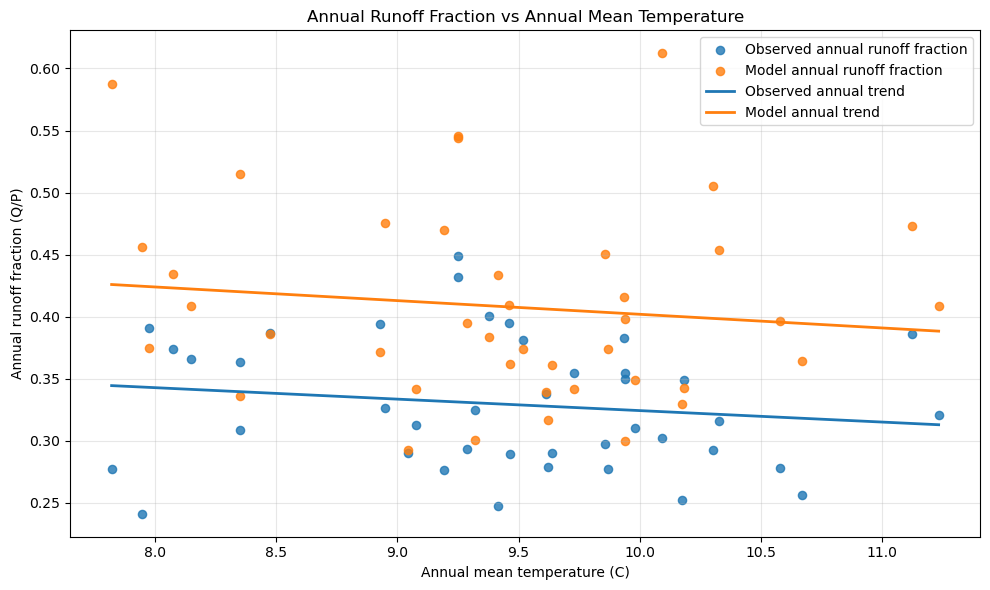

Observed annual slope: -0.0092 per C
Model annual slope:    -0.0110 per C
   year    temp_C    rf_obs    rf_mod
0  1980  7.973034  0.390967  0.374475
1  1981  8.474816  0.387067  0.385817
2  1982  9.249956  0.449185  0.545616
3  1983  9.250297  0.431927  0.544038
4  1984  8.350761  0.363454  0.514640


In [49]:
# Annual-scale relationship (reduces seasonal effects)
annual_df = check_df.copy()
annual_df = annual_df[['Date', 'temperature', 'precip_mm_day', 'q_obs_mm_day', 'days_in_month']].copy()
annual_df['year'] = annual_df['Date'].dt.year
annual_df['model_q_mm_day'] = best_sim_q

# Convert rates back to monthly depths before annual aggregation
annual_df['precip_mm_month'] = annual_df['precip_mm_day'] * annual_df['days_in_month']
annual_df['q_obs_mm_month'] = annual_df['q_obs_mm_day'] * annual_df['days_in_month']
annual_df['q_mod_mm_month'] = annual_df['model_q_mm_day'] * annual_df['days_in_month']

annual_agg = annual_df.groupby('year').agg(
    temp_C=('temperature', 'mean'),
    precip_mm=('precip_mm_month', 'sum'),
    q_obs_mm=('q_obs_mm_month', 'sum'),
    q_mod_mm=('q_mod_mm_month', 'sum')
).reset_index()

annual_agg = annual_agg[annual_agg['precip_mm'] > 1e-6].copy()
annual_agg['rf_obs'] = annual_agg['q_obs_mm'] / annual_agg['precip_mm']
annual_agg['rf_mod'] = annual_agg['q_mod_mm'] / annual_agg['precip_mm']

x = annual_agg['temp_C'].to_numpy()
y_obs = annual_agg['rf_obs'].to_numpy()
y_mod = annual_agg['rf_mod'].to_numpy()

obs_fit = np.polyfit(x, y_obs, 1)
mod_fit = np.polyfit(x, y_mod, 1)
obs_line = np.poly1d(obs_fit)
mod_line = np.poly1d(mod_fit)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, s=35, alpha=0.8, label='Observed annual runoff fraction')
plt.scatter(x, y_mod, s=35, alpha=0.8, label='Model annual runoff fraction')

x_line = np.linspace(np.min(x), np.max(x), 200)
plt.plot(x_line, obs_line(x_line), linewidth=2, label='Observed annual trend')
plt.plot(x_line, mod_line(x_line), linewidth=2, label='Model annual trend')

plt.xlabel('Annual mean temperature (C)')
plt.ylabel('Annual runoff fraction (Q/P)')
plt.title('Annual Runoff Fraction vs Annual Mean Temperature')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Observed annual slope: {obs_fit[0]:.4f} per C')
print(f'Model annual slope:    {mod_fit[0]:.4f} per C')
print(annual_agg[['year', 'temp_C', 'rf_obs', 'rf_mod']].head())

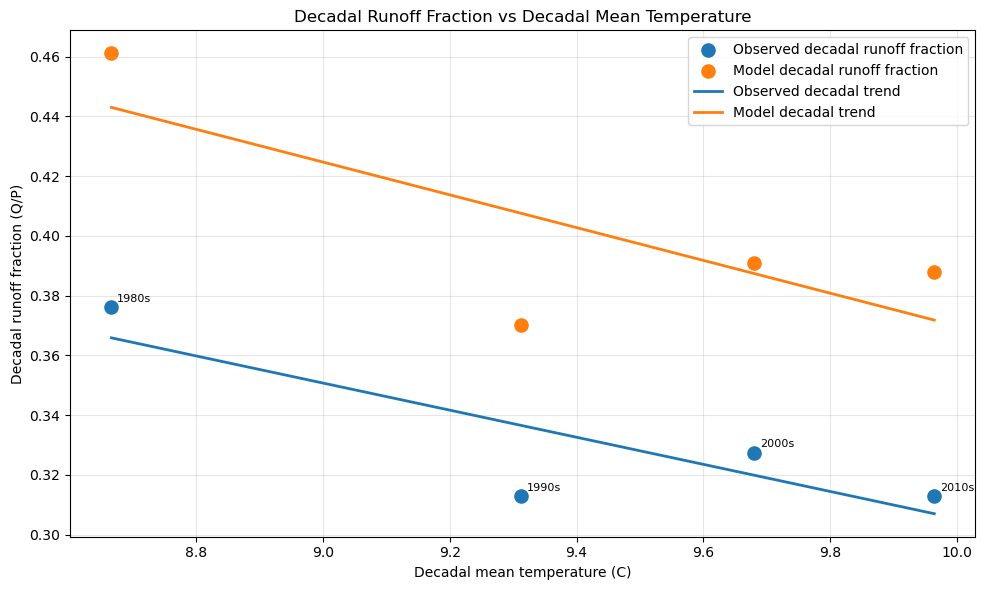

Observed decadal slope: -0.0454 per C
Model decadal slope:    -0.0549 per C
   decade    temp_C    rf_obs    rf_mod
0    1980  8.665950  0.376101  0.461118
1    1990  9.312550  0.312812  0.370016
2    2000  9.680561  0.327440  0.390801
3    2010  9.964332  0.312834  0.387812


In [52]:
# 10-year block analysis (decadal scale)
# Use annual aggregates, then average/sum into full decades.
decadal_source = annual_agg.copy()
decadal_source['decade'] = (decadal_source['year'] // 10) * 10

# Keep only full 10-year blocks so each point is comparable.
full_decades = decadal_source.groupby('decade')['year'].count()
full_decades = full_decades[full_decades >= 10].index

decadal_agg = decadal_source[decadal_source['decade'].isin(full_decades)].groupby('decade').agg(
    temp_C=('temp_C', 'mean'),
    precip_mm=('precip_mm', 'sum'),
    q_obs_mm=('q_obs_mm', 'sum'),
    q_mod_mm=('q_mod_mm', 'sum')
).reset_index()

decadal_agg['rf_obs'] = decadal_agg['q_obs_mm'] / decadal_agg['precip_mm']
decadal_agg['rf_mod'] = decadal_agg['q_mod_mm'] / decadal_agg['precip_mm']

x_dec = decadal_agg['temp_C'].to_numpy()
y_dec_obs = decadal_agg['rf_obs'].to_numpy()
y_dec_mod = decadal_agg['rf_mod'].to_numpy()

obs_fit_dec = np.polyfit(x_dec, y_dec_obs, 1)
mod_fit_dec = np.polyfit(x_dec, y_dec_mod, 1)
obs_line_dec = np.poly1d(obs_fit_dec)
mod_line_dec = np.poly1d(mod_fit_dec)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x_dec, y_dec_obs, s=90, label='Observed decadal runoff fraction')
plt.scatter(x_dec, y_dec_mod, s=90, label='Model decadal runoff fraction')

x_line_dec = np.linspace(np.min(x_dec), np.max(x_dec), 200)
plt.plot(x_line_dec, obs_line_dec(x_line_dec), linewidth=2, label='Observed decadal trend')
plt.plot(x_line_dec, mod_line_dec(x_line_dec), linewidth=2, label='Model decadal trend')

for _, row in decadal_agg.iterrows():
    plt.annotate(f"{int(row['decade'])}s", (row['temp_C'], row['rf_obs']), textcoords='offset points', xytext=(4, 4), fontsize=8)

plt.xlabel('Decadal mean temperature (C)')
plt.ylabel('Decadal runoff fraction (Q/P)')
plt.title('Decadal Runoff Fraction vs Decadal Mean Temperature')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Observed decadal slope: {obs_fit_dec[0]:.4f} per C')
print(f'Model decadal slope:    {mod_fit_dec[0]:.4f} per C')
print(decadal_agg[['decade', 'temp_C', 'rf_obs', 'rf_mod']])

### Main body

In [26]:
# Import hourly data, resample to daily, and clip to Exercise 3 period (2010-2012)
from pathlib import Path
import pandas as pd

grdc_obs = pd.read_csv(
    "/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt",
    encoding="latin-1",
    sep=";",
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = "date"
grdc_obs.columns = ["Observations from GRDC"]

shape_area = 28191724718

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))

df_p = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
df_e = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

# Parse hourly timestamp format like 20110101T00
for frame in (df_p, df_e):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

p_col = [c for c in df_p.columns if c not in ['system:index', 'time']][0]
e_col = [c for c in df_e.columns if c not in ['system:index', 'time']][0]

# Sum hourly depths to daily totals (ERA5 hourly totals are accumulated depth per hour)
df_p_daily = (
    df_p.set_index('time')[[p_col]]
    .resample('D').sum()
    .rename(columns={p_col: 'precip_m_day'})
)

df_e_daily = (
    df_e.set_index('time')[[e_col]]
    .resample('D').sum()
    .rename(columns={e_col: 'evap_m_day'})
)

# Clip to the Exercise 3 period
start_ex3 = pd.Timestamp('2010-01-01')
end_ex3 = pd.Timestamp('2012-12-31')

df_p_daily = df_p_daily.loc[start_ex3:end_ex3]
df_e_daily = df_e_daily.loc[start_ex3:end_ex3]

# Overwrite df_p and df_e with daily clipped data for downstream use
df_p = df_p_daily.copy()
df_e = df_e_daily.copy()

print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731
Daily evaporation range:   2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731


,precip_m_day,evap_m_day
time,,
2011-01-01,0.000623,-0.000018
2011-01-02,0.000219,-0.000168
2011-01-03,0.000124,-0.000085


In [28]:
## Daily Monte Carlo setup for hbv_bmi_project
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
from hbv_bmi_project import HBV_Bmi

start_mc = pd.Timestamp('2011-01-01')
end_mc = pd.Timestamp('2014-12-31')

base_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Ensure daily forcing exists and covers the requested window; otherwise rebuild from hourly files.
need_rebuild = True
if ('df_p' in globals()) and ('df_e' in globals()):
    try:
        need_rebuild = (
            (df_p.index.min() > start_mc) or (df_p.index.max() < end_mc) or
            (df_e.index.min() > start_mc) or (df_e.index.max() < end_mc)
        )
    except Exception:
        need_rebuild = True

if need_rebuild:
    df_p_h = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
    df_e_h = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

    for frame in (df_p_h, df_e_h):
        frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

    p_col = [c for c in df_p_h.columns if c not in ['system:index', 'time']][0]
    e_col = [c for c in df_e_h.columns if c not in ['system:index', 'time']][0]

    df_p = df_p_h.set_index('time')[[p_col]].resample('D').sum().rename(columns={p_col: 'precip_m_day'})
    df_e = df_e_h.set_index('time')[[e_col]].resample('D').sum().rename(columns={e_col: 'evap_m_day'})

# Convert forcing to mm/day and ensure positive PET sign
daily_forcing = pd.concat([df_p, df_e], axis=1).loc[start_mc:end_mc].copy()
daily_forcing = daily_forcing.asfreq('D')
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'].interpolate(limit_direction='both') * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day'].interpolate(limit_direction='both')).clip(lower=0) * 1000.0

# Build daily temperature anomaly from hourly ERA5 temperature
temp_df = pd.read_csv(base_path / 'Moselle_ECMWF_ERA5_LAND_HOURLY_temperature_2m_2011-01-01_2017-12-31.csv')
temp_df['time'] = pd.to_datetime(temp_df['system:index'].astype(str), format='%Y%m%dT%H')
temp_col = 'temperature_2m' if 'temperature_2m' in temp_df.columns else [c for c in temp_df.columns if c not in ['system:index', 'time']][0]
temp_df['temperature_C'] = temp_df[temp_col] - 273.15
temp_hourly = temp_df.set_index('time')['temperature_C'].sort_index()
temp_daily = temp_hourly.resample('D').mean()

daily_forcing['temp_C'] = temp_daily.reindex(daily_forcing.index).interpolate(limit_direction='both').to_numpy()
daily_forcing['delT_C'] = daily_forcing['temp_C'] - daily_forcing['temp_C'].mean()

# Daily observed Q in mm/day
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']
elif 'q_m3s' not in grdc.columns:
    grdc = grdc.copy()
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Explicit daily checks for all input time series
if pd.infer_freq(daily_forcing.index) != 'D':
    raise ValueError('Forcing index is not daily.')

# Calibration score period excludes warmup year
cal_mask = (daily_forcing.index >= pd.Timestamp('2012-01-01')) & (daily_forcing.index <= pd.Timestamp('2014-12-31'))

# In-memory forcing DataArrays for hbv_bmi_project
pr_da_mc = xr.DataArray(daily_forcing['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='pr')
pet_da_mc = xr.DataArray(daily_forcing['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='evspsblpot')
tas_da_mc = xr.DataArray(daily_forcing['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='tas')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Calibration score period (after warmup): 2012-01-01 to 2014-12-31')
print('Input frequency (P/PET/T/Qobs): daily')
print('delT range (C):', float(np.nanmin(daily_forcing['delT_C'])), 'to', float(np.nanmax(daily_forcing['delT_C'])))

MC forcing period: 2011-01-01 00:00:00 to 2014-12-31 00:00:00 | n = 1461
Calibration score period (after warmup): 2012-01-01 to 2014-12-31
Input frequency (P/PET/T/Qobs): daily
delT range (C): -20.41714946977551 to 16.051747263690693


In [ ]:
# MC simulation for hbv_bmi_project (2011-2014 with 2011 warmup, score on 2012-2014)
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

#                      Imax, Ce, Sumax0,beta, Pmax, Tlag, Kf, Ks, Gamma
ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc = 10000
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)

    cfg = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m = HBV_Bmi()
    m.initialize(cfg)
    m.set_pars(p)

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
print('Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily['params'])
summary_daily

Valid runs: 1000 / 1000
Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[3.08657867e+00 5.98606898e-01 3.94676894e+02 3.42280135e+00
 1.25700631e-01 4.19592949e+00 1.87717829e-01 9.86649571e-03
 1.02599769e-02]


,metric,value
0,NSE_cal_2012_2014,0.796392
1,logNSE_cal_2012_2014,0.763218
2,rel_bias_cal_2012_2014,0.019416


In [29]:
## nse 0.814, log NSE 0.646

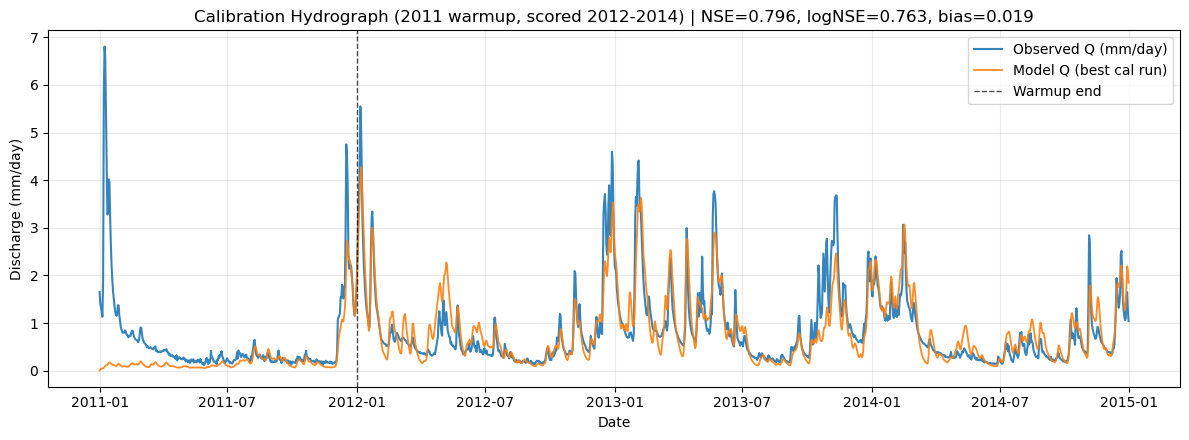

In [31]:
# Calibration hydrograph (forcing 2011-2014; metrics on 2012-2014 after warmup)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best, label='Model Q (best cal run)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('2012-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f'Calibration Hydrograph (2011 warmup, scored 2012-2014) | '
    f"NSE={best_daily['nse_cal']:.3f}, logNSE={best_daily['lognse_cal']:.3f}, bias={best_daily['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Validation run (2015-2016) with best calibrated parameters from 2011-2014 experiment
start_val = pd.Timestamp('2015-01-01')
end_val = pd.Timestamp('2017-12-31')

# Reuse daily forcing tables if they already cover validation; otherwise rebuild from hourly files
need_rebuild_val = True
if ('df_p' in globals()) and ('df_e' in globals()):
    try:
        need_rebuild_val = (
            (df_p.index.min() > start_val) or (df_p.index.max() < end_val) or
            (df_e.index.min() > start_val) or (df_e.index.max() < end_val)
        )
    except Exception:
        need_rebuild_val = True

if need_rebuild_val:
    df_p_h = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
    df_e_h = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')
    for frame in (df_p_h, df_e_h):
        frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')
    p_col = [c for c in df_p_h.columns if c not in ['system:index', 'time']][0]
    e_col = [c for c in df_e_h.columns if c not in ['system:index', 'time']][0]
    df_p = df_p_h.set_index('time')[[p_col]].resample('D').sum().rename(columns={p_col: 'precip_m_day'})
    df_e = df_e_h.set_index('time')[[e_col]].resample('D').sum().rename(columns={e_col: 'evap_m_day'})

daily_forcing_val = pd.concat([df_p, df_e], axis=1).loc[start_val:end_val].copy()
daily_forcing_val = daily_forcing_val.asfreq('D')
daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both') * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')).clip(lower=0) * 1000.0

# Daily temperature anomaly from hourly temperature
if 'temp_daily' not in globals():
    temp_df = pd.read_csv(base_path / 'Moselle_ECMWF_ERA5_LAND_HOURLY_temperature_2m_2011-01-01_2017-12-31.csv')
    temp_df['time'] = pd.to_datetime(temp_df['system:index'].astype(str), format='%Y%m%dT%H')
    temp_col = 'temperature_2m' if 'temperature_2m' in temp_df.columns else [c for c in temp_df.columns if c not in ['system:index', 'time']][0]
    temp_df['temperature_C'] = temp_df[temp_col] - 273.15
    temp_hourly = temp_df.set_index('time')['temperature_C'].sort_index()
    temp_daily = temp_hourly.resample('D').mean()

daily_forcing_val['temp_C'] = temp_daily.reindex(daily_forcing_val.index).interpolate(limit_direction='both').to_numpy()
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

q_obs_val = (
    grdc['q_m3s']
    .loc[start_val:end_val]
    .reindex(daily_forcing_val.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

if pd.infer_freq(daily_forcing_val.index) != 'D':
    raise ValueError('Validation forcing index is not daily.')

pr_da_val = xr.DataArray(daily_forcing_val['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='pr')
pet_da_val = xr.DataArray(daily_forcing_val['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='evspsblpot')
tas_da_val = xr.DataArray(daily_forcing_val['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='tas')

cfg_val = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val = HBV_Bmi()
m_val.initialize(cfg_val)
m_val.set_pars(best_daily['params'])

sim_val = []
while m_val.current_timestep < m_val.end_timestep:
    m_val.update()
    out = np.array([0.0])
    m_val.get_value('Q', out)
    sim_val.append(out[0])
sim_val = np.asarray(sim_val, dtype=float)

nse_val = nse(q_obs_val, sim_val)
lognse_val = log_nse(q_obs_val, sim_val)
rb_val = rel_bias(q_obs_val, sim_val)

summary_val = pd.DataFrame({
    'metric': ['NSE_val_2015_2016', 'logNSE_val_2015_2016', 'rel_bias_val_2015_2016'],
    'value': [nse_val, lognse_val, rb_val],
})

print('Validation period:', daily_forcing_val.index.min(), 'to', daily_forcing_val.index.max(), '| n =', len(daily_forcing_val))
print('Input frequency (P/PET/T/Qobs): daily')
summary_val

Validation period: 2015-01-01 00:00:00 to 2017-12-30 00:00:00 | n = 1095
Input frequency (P/PET/T/Qobs): daily


,metric,value
0,NSE_val_2015_2016,0.620563
1,logNSE_val_2015_2016,0.338789
2,rel_bias_val_2015_2016,-0.199545


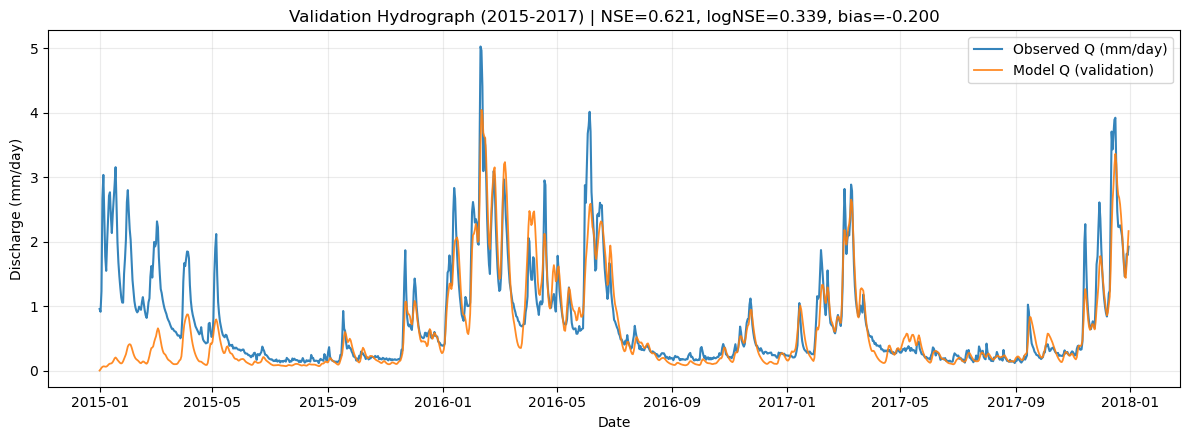

In [33]:
# Validation hydrograph
plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing_val.index, q_obs_val, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing_val.index, sim_val, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (2015-2017) | NSE={nse_val:.3f}, logNSE={lognse_val:.3f}, bias={rb_val:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Slow-Dynamics Gamma Experiment
This section keeps HBV at daily timestep but drives `Su_max` with a **smoothed temperature anomaly** instead of raw daily temperature.

Concept:
- Keep rainfall, PET, and discharge daily.
- Replace `delT_C` with `delT_slow_C` using an exponential moving average timescale (`tau_days`).
- Calibrate and validate with the same period split to compare against the fast daily-temperature gamma setup.

In [34]:
# Build slow temperature anomaly for calibration period
if 'daily_forcing' not in globals():
    raise RuntimeError('Run the daily setup cell first so daily_forcing exists.')

tau_days = 365  # Characteristic timescale for slow soil-property response
alpha_slow = 1.0 - np.exp(-1.0 / tau_days)

daily_forcing_slow = daily_forcing.copy()
daily_forcing_slow['temp_slow_C'] = daily_forcing_slow['temp_C'].ewm(alpha=alpha_slow, adjust=False).mean()
daily_forcing_slow['delT_slow_C'] = daily_forcing_slow['temp_slow_C'] - daily_forcing_slow['temp_slow_C'].mean()

tas_da_mc_slow = xr.DataArray(
    daily_forcing_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_slow.index},
    dims=('time',),
    name='tas',
)

print('Slow-dynamics gamma setup ready.')
print('tau_days =', tau_days, '| alpha =', round(alpha_slow, 6))
print('delT_fast range:', float(daily_forcing['delT_C'].min()), 'to', float(daily_forcing['delT_C'].max()))
print('delT_slow range:', float(daily_forcing_slow['delT_slow_C'].min()), 'to', float(daily_forcing_slow['delT_slow_C'].max()))

Slow-dynamics gamma setup ready.
tau_days = 365 | alpha = 0.002736
delT_fast range: -20.41714946977551 to 16.051747263690693
delT_slow range: -8.295527907608669 to 4.119403391261846


In [36]:
# MC calibration using slow-dynamics gamma (same periods and bounds)
if 'cal_mask' not in globals() or 'q_obs_daily' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the daily setup cell first (it defines forcing and calibration masks).')

if 'nse' not in globals() or 'log_nse' not in globals() or 'rel_bias' not in globals():
    raise RuntimeError('Run the MC metric-definition cell first (nse/log_nse/rel_bias).')

# Reuse current bounds if present; otherwise define defaults
if 'ParMinn_mc' not in globals() or 'ParMaxn_mc' not in globals():
    ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
    ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc_slow = 1000
results_mc_slow = []
obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc_slow):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg_slow = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc_slow,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m_slow = HBV_Bmi()
    m_slow.initialize(cfg_slow)
    m_slow.set_pars(p)

    sim = []
    while m_slow.current_timestep < m_slow.end_timestep:
        m_slow.update()
        out = np.array([0.0])
        m_slow.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc_slow.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc_slow:
    raise RuntimeError('No valid slow-gamma MC runs found.')

best_daily_slow = max(results_mc_slow, key=lambda d: d['nse_cal'])
sim_daily_best_slow = best_daily_slow['sim_mm_day']

summary_daily_slow = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014_slowGamma', 'logNSE_cal_2012_2014_slowGamma', 'rel_bias_cal_2012_2014_slowGamma'],
    'value': [best_daily_slow['nse_cal'], best_daily_slow['lognse_cal'], best_daily_slow['rb_cal']],
})

print('Valid slow-gamma runs:', len(results_mc_slow), '/', N_mc_slow)
print('Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily_slow['params'])
summary_daily_slow

Valid slow-gamma runs: 1000 / 1000
Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[ 2.34104329e-01  5.11984401e-01  2.88722671e+02  2.35258354e+00
  6.16211574e-02  3.22100659e+00  1.64617867e-01  1.11805294e-02
 -1.26263999e-02]


,metric,value
0,NSE_cal_2012_2014_slowGamma,0.835346
1,logNSE_cal_2012_2014_slowGamma,0.739585
2,rel_bias_cal_2012_2014_slowGamma,0.067869


In [37]:
# Validation with slow-dynamics gamma (same validation period)
if 'start_val' not in globals():
    start_val = pd.Timestamp('2015-01-01')
if 'end_val' not in globals():
    end_val = pd.Timestamp('2017-12-31')

if 'daily_forcing_val' not in globals():
    raise RuntimeError('Run the existing validation setup cell first so daily_forcing_val exists.')

# Build slow temperature over a longer continuous index to avoid edge effects at validation start
slow_full_index = pd.date_range(start=daily_forcing.index.min(), end=daily_forcing_val.index.max(), freq='D')
temp_full = temp_daily.reindex(slow_full_index).interpolate(limit_direction='both')
temp_slow_full = temp_full.ewm(alpha=alpha_slow, adjust=False).mean()
temp_slow_val = temp_slow_full.reindex(daily_forcing_val.index)

daily_forcing_val_slow = daily_forcing_val.copy()
daily_forcing_val_slow['temp_slow_C'] = temp_slow_val.to_numpy()
daily_forcing_val_slow['delT_slow_C'] = daily_forcing_val_slow['temp_slow_C'] - daily_forcing_val_slow['temp_slow_C'].mean()

tas_da_val_slow = xr.DataArray(
    daily_forcing_val_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_val_slow.index},
    dims=('time',),
    name='tas',
)

cfg_val_slow = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val_slow,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val_slow = HBV_Bmi()
m_val_slow.initialize(cfg_val_slow)
m_val_slow.set_pars(best_daily_slow['params'])

sim_val_slow = []
while m_val_slow.current_timestep < m_val_slow.end_timestep:
    m_val_slow.update()
    out = np.array([0.0])
    m_val_slow.get_value('Q', out)
    sim_val_slow.append(out[0])
sim_val_slow = np.asarray(sim_val_slow, dtype=float)

nse_val_slow = nse(q_obs_val, sim_val_slow)
lognse_val_slow = log_nse(q_obs_val, sim_val_slow)
rb_val_slow = rel_bias(q_obs_val, sim_val_slow)

summary_val_slow = pd.DataFrame({
    'metric': ['NSE_val_slowGamma', 'logNSE_val_slowGamma', 'rel_bias_val_slowGamma'],
    'value': [nse_val_slow, lognse_val_slow, rb_val_slow],
})

summary_val_slow

,metric,value
0,NSE_val_slowGamma,0.763899
1,logNSE_val_slowGamma,0.632636
2,rel_bias_val_slowGamma,-0.069189


In [38]:
# Compare fast daily-gamma vs slow-dynamics gamma
compare_gamma = pd.DataFrame({
    'scenario': ['fast_gamma_cal', 'slow_gamma_cal', 'fast_gamma_val', 'slow_gamma_val'],
    'NSE': [best_daily['nse_cal'], best_daily_slow['nse_cal'], nse_val, nse_val_slow],
    'logNSE': [best_daily['lognse_cal'], best_daily_slow['lognse_cal'], lognse_val, lognse_val_slow],
    'rel_bias': [best_daily['rb_cal'], best_daily_slow['rb_cal'], rb_val, rb_val_slow],
})

gamma_compare = pd.DataFrame({
    'scenario': ['fast_gamma', 'slow_gamma'],
    'Gamma': [float(best_daily['params'][8]), float(best_daily_slow['params'][8])],
    'tau_days': [np.nan, float(tau_days)],
})

compare_gamma, gamma_compare

(         scenario       NSE    logNSE  rel_bias
 0  fast_gamma_cal  0.796392  0.763218  0.019416
 1  slow_gamma_cal  0.835346  0.739585  0.067869
 2  fast_gamma_val  0.620563  0.338789 -0.199545
 3  slow_gamma_val  0.763899  0.632636 -0.069189,
      scenario     Gamma  tau_days
 0  fast_gamma  0.010260       NaN
 1  slow_gamma -0.012626     365.0)

In [ ]:
## Also try making soil 

### Old code for processing monthly dataframes 

In [ ]:
# df = pd.read_csv("ERA5_Temp_1980_2026.csv")

# # Parse year and month from the index (format: YYYYMM)
# df['year'] = df['system:index'].astype(str).str[:4].astype(int)
# df['month'] = df['system:index'].astype(str).str[4:6].astype(int)
 
# # Convert temperature from Kelvin to Celsius
# df['temperature_C'] = df['temperature_2m'] - 273.15
 
# # Calculate mean annual temperature (average all months per year)
# annual_mean = df.groupby('year')['temperature_C'].mean()
 
# # Assign each year to a decade (e.g., 1980-1989 → 1980s)
# annual_mean_df = annual_mean.reset_index()
# annual_mean_df.columns = ['year', 'mean_annual_temp_C']
# annual_mean_df['decade'] = (annual_mean_df['year'] // 10) * 10
 
# # Calculate mean temperature per decade
# decadal_mean = annual_mean_df.groupby('decade')['mean_annual_temp_C'].mean().reset_index()
# decadal_mean.columns = ['decade', 'mean_decadal_temp_C']
 
# # print("Mean Annual Temperature per Year:")
# # print(annual_mean_df.to_string(index=False))
# # print("\nMean Temperature per Decade:")
# # print(decadal_mean.to_string(index=False))
 
# # # Pivot table: rows = years, columns = months (Jan=1 ... Dec=12)
# # pivot = df.pivot_table(index='year', columns='month', values='temperature_C')
# # pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# # pivot.index.name = 'year'
 
# #print("\nMonthly Mean Temperature per Year (°C):")
# #print(pivot.round(2).to_string())

Mean Annual Temperature per Year:
 year  mean_annual_temp_C  decade
 1980            7.973034    1980
 1981            8.474816    1980
 1982            9.249956    1980
 1983            9.250297    1980
 1984            8.350761    1980
 1985            7.820802    1980
 1986            8.149693    1980
 1987            8.072648    1980
 1988            9.459149    1980
 1989            9.858341    1980
 1990            9.866679    1990
 1991            8.950346    1990
 1992            9.638510    1990
 1993            9.042281    1990
 1994           10.184077    1990
 1995            9.518560    1990
 1996            7.946916    1990
 1997            9.287314    1990
 1998            9.076644    1990
 1999            9.614176    1990
 2000            9.938774    2000
 2001            9.376367    2000
 2002            9.934531    2000
 2003           10.092163    2000
 2004            9.192590    2000
 2005            9.413167    2000
 2006            9.978638    2000
 2007         

In [1]:
# # Extract monthly mean temperatures for 1980-2020 as a 1D array
# temp_1980_2020 = pivot.loc[1980:2020].values.flatten()
# print(f"Monthly temperature array shape: {temp_1980_2020.shape}")
# print(f"First 12 values (Jan-Dec 1980): {temp_1980_2020[:12]}")
# print(f"Last 12 values (Jan-Dec 2020): {temp_1980_2020[-12:]}")
# print(f"\nArray: {temp_1980_2020}")

In [ ]:
# ## Monthly df
# # Load precipitation and evaporation monthly data
# precip_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv")
# evap_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv")

# # Parse the system:index column (YYYYMM format) and filter to 1980-2020
# precip_df['yyyymm'] = precip_df['system:index']
# precip_df = precip_df[(precip_df['yyyymm'] >= 198001) & (precip_df['yyyymm'] <= 202012)].reset_index(drop=True)

# evap_df['yyyymm'] = evap_df['system:index']
# evap_df = evap_df[(evap_df['yyyymm'] >= 198001) & (evap_df['yyyymm'] <= 202012)].reset_index(drop=True)

# # Create monthly date index for 1980-2020 (Jan 1980 to Dec 2020)
# date_range_monthly = pd.date_range(start='1980-01-01', end='2020-12-31', freq='MS')

# # Aggregate daily discharge observations to monthly mean
# grdc_monthly = grdc_obs.copy()
# grdc_monthly['year'] = grdc_monthly.index.year
# grdc_monthly['month'] = grdc_monthly.index.month
# discharge_monthly = grdc_monthly.groupby(['year', 'month'])['Observations from GRDC'].mean().reset_index()
# discharge_monthly['date'] = pd.to_datetime(discharge_monthly[['year', 'month']].assign(day=1))
# discharge_monthly = discharge_monthly[(discharge_monthly['year'] >= 1980) & (discharge_monthly['year'] <= 2020)].sort_values('date').reset_index(drop=True)

# # Create the combined monthly dataframe
# monthly_df = pd.DataFrame({
#     'Date': date_range_monthly.values,
#     'precipitation': precip_df['total_precipitation_sum'].values,
#     'evaporation': evap_df[evap_df.columns[1]].values,  # Get the second column (evaporation values)
#     'temperature': temp_1980_2020,
#     'discharge': discharge_monthly['Observations from GRDC'].values,
#     'delT': temp_1980_2020 - np.mean(temp_1980_2020)
# })

# print("Monthly DataFrame (1980-2020):")
# print(monthly_df.head(12))
# print(f"\nShape: {monthly_df.shape}")
# #print(f"\nColumn dtypes:\n{monthly_df.dtypes}")
# #print(f"\nSummary statistics:\n{monthly_df.describe()}")

Monthly DataFrame (1980-2020):
         Date  precipitation  evaporation  temperature   discharge       delT
0  1980-01-01       0.077218    -0.006487    -1.001031  592.322581 -10.451440
1  1980-02-01       0.081914    -0.021555     3.847232  896.241379  -5.603177
2  1980-03-01       0.089754    -0.037676     4.629214  269.935484  -4.821195
3  1980-04-01       0.060644    -0.064560     6.306908  293.433333  -3.143501
4  1980-05-01       0.073371    -0.092885    10.861671  180.354839   1.411262
5  1980-06-01       0.123058    -0.089279    13.827272  166.233333   4.376863
6  1980-07-01       0.144232    -0.083601    14.543447  582.290323   5.093038
7  1980-08-01       0.100759    -0.084409    16.574180  194.806452   7.123771
8  1980-09-01       0.040687    -0.060524    14.639331  135.933333   5.188922
9  1980-10-01       0.080884    -0.034231     8.349362  213.000000  -1.101047
10 1980-11-01       0.068660    -0.015680     2.921443  261.466667  -6.528966
11 1980-12-01       0.091563    -